<a href="https://colab.research.google.com/github/LukeXboy/Spotify-User-Churn-prediction/blob/main/Spotify_User_Churn_Prediction_(Logistic_Regression_Part).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from google.colab import files
uploaded = files.upload()

Saving spotify_churn_dataset.csv to spotify_churn_dataset.csv


In [ ]:
#seperate categorical and numeric data
raw_data = pd.read_csv('/content/spotify_churn_dataset.csv')
gender = pd.get_dummies(raw_data['gender']).astype(int)
country = pd.get_dummies(raw_data['country']).astype(int)
subscription_type = pd.get_dummies(raw_data['subscription_type']).astype(int)
device_type = pd.get_dummies(raw_data['device_type']).astype(int)
categorical_data = pd.concat([gender, country, subscription_type, device_type,raw_data[['offline_listening','is_churned']]], axis=1)
numeric_data = pd.concat([raw_data[['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week']]])

#Normalize the numeric data
scaler = StandardScaler()
numeric_data = pd.DataFrame(scaler.fit_transform(numeric_data), columns = ['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week'])

#combine the two types of data together
combined_data = pd.concat([numeric_data, categorical_data], axis=1)
combined_data

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,Female,Male,Other,AU,CA,...,US,Family,Free,Premium,Student,Desktop,Mobile,Web,offline_listening,is_churned
0,1.282452,-1.524434,-0.953574,-0.576827,1.766611,1,0,0,0,1,...,0,0,1,0,0,1,0,0,0,1
1,-0.365956,-0.155555,0.417349,0.229702,-0.509938,0,0,1,0,0,...,0,1,0,0,0,0,0,1,1,0
2,0.026522,0.534836,-0.426296,-1.498575,-0.509938,0,1,0,1,0,...,0,0,0,1,0,0,1,0,1,1
3,-1.229408,-1.405401,-1.691763,0.056875,-0.509938,1,0,0,0,1,...,0,0,0,0,1,0,1,0,1,0
4,-0.679939,1.141904,0.241590,0.344921,-0.509938,0,0,1,0,0,...,1,1,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.497495,0.987161,-0.496599,-0.000735,-0.509938,0,0,1,0,0,...,0,0,0,0,1,0,1,0,1,1
7996,-0.287461,-1.107819,0.487653,1.669933,-0.509938,0,1,0,1,0,...,0,0,0,1,0,0,1,0,1,0
7997,-1.621886,-0.869753,0.417349,0.172093,-0.142752,1,0,0,0,0,...,1,0,1,0,0,1,0,0,0,0
7998,-0.287461,1.082388,1.542209,-0.173562,-0.509938,1,0,0,0,0,...,0,0,0,0,1,1,0,0,1,0


In [ ]:
#check data imbalance
pct_not_churned = combined_data['is_churned'].value_counts()[0]/len(combined_data)
pct_churned = combined_data['is_churned'].value_counts()[1]/len(combined_data)
print('Percentage of not churned: ', pct_not_churned)
print('Percentage of churned: ', pct_churned)

Percentage of not churned:  0.741125
Percentage of churned:  0.258875


**Users who are not churned have triple size of users that are churned, imbalanced data.**

In [ ]:
#Train, validation, test split
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(combined_data, test_size = 0.4, random_state=1513)
validation_data, test_data = train_test_split(test_data, test_size = 0.5, random_state=1513)

In [ ]:
#Split X and y
X_train = train_data.drop('is_churned', axis=1)
y_train = train_data['is_churned']
X_validation = validation_data.drop('is_churned', axis=1)
y_validation = validation_data['is_churned']
X_test = test_data.drop('is_churned', axis=1)
y_test = test_data['is_churned']

We will tune 4 hyperparameters in this case: **penalty type** (L1, L2 and elasticnet), the regularization strength **lambda** (**C=1/lambda** in python), **class_weight** (since we have imbalanced data) and **classification threshold**. We will use grid search for hyperparameter combination.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
#l1,l2 penalty logistic regression
penalty = ['l1','l2']
C = [0.001,0.01,0.1,1,5,10]
class_weight = [None,'balanced']
threshold = np.linspace(0.1,0.9,9)
f1_score_list = []
best_parameters = None
best_threshold = 0
best_f1 = -1
best_model = None
for p in penalty:
  for c in C:
    for weight in class_weight:
      for t in threshold:
        model = LogisticRegression(solver = 'saga',max_iter=5000,
                                  penalty = p, C = c, class_weight = weight)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_validation)[:,1]
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_validation, y_pred)
        f1_score_list.append(f1)

        if f1 > best_f1:
          best_f1 = f1
          best_parameters = {'Penalty':p, 'C':c, 'class_weight':weight, 'threshold':t}
          best_threshold = t
          best_model = model

In [ ]:
best_f1

0.4012006003001501

In [ ]:
#Elasticnet penalty logistic regression
C = [0.001,0.01,0.1,1,5,10]
class_weight = [None,'balanced']
threshold = np.linspace(0.1,0.9,9)
l1_ratios = np.linspace(0,1,11)
f1_score_list_els = []
best_parameters_els = None
best_threshold_els = 0
best_f1_els = -1
best_model_els = None
for l1_rt in l1_ratios:
  for c in C:
    for weight in class_weight:
      for t in threshold:
        model = LogisticRegression(solver = 'saga',max_iter=5000,
                                    penalty = 'elasticnet', C = c,
                                  class_weight = weight, l1_ratio= l1_rt)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_validation)[:,1]
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_validation, y_pred)
        f1_score_list_els.append(f1)

        if f1 > best_f1_els:
          best_f1_els = f1
          best_parameters_els = {'l1 ratio':l1_rt, 'C':c, 'class_weight':weight, 'threshold':t}
          best_threshold_els = t
          best_model_els = model

In [ ]:
best_f1_els

0.4012006003001501

In [ ]:
best_parameters_els

{'l1 ratio': np.float64(0.1),
 'C': 1,
 'class_weight': 'balanced',
 'threshold': np.float64(0.4)}

In [ ]:
from sklearn.metrics import auc, roc_curve
from sklearn.metrics import recall_score
best_final_model = LogisticRegression(solver = 'saga',max_iter=5000,
                                C = 1, penalty = 'elasticnet',class_weight='balanced',
                                l1_ratio = 0.1)
best_final_model.fit(X_train,y_train)
y_pred_proba = best_final_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.4).astype(int)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f'The best model test accuracy score is {accuracy_score(y_test, y_pred)}')
print(f'The best model test f1 score is {f1_score(y_test, y_pred)}')
print(f'The best model test recall is {recall_score(y_test, y_pred)}')
print(f'The best model test AUC is {roc_auc}')

The best model test accuracy score is 0.266875
The best model test f1 score is 0.41901931649331353
The best model test recall is 1.0
The best model test AUC is 0.531699978508489


Confusion matrix: 
[[   4 1173]
 [   0  423]]


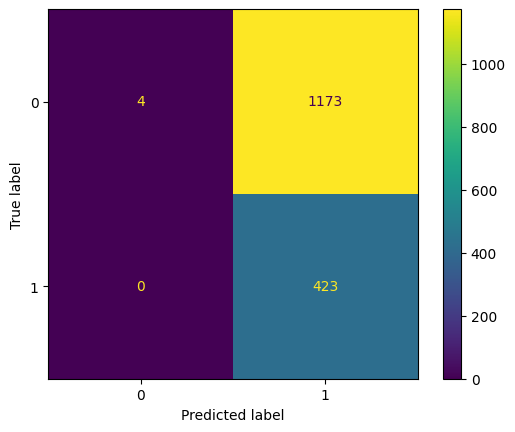

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(f'Confusion matrix: \n{cm}')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_final_model.classes_)
disp.plot()

In [ ]:
# We will take the absolute value of the model coefficient of each feature as feature importance
import matplotlib.pyplot as plt
import numpy as np
raw_feature_importance = best_final_model.coef_[0]

fi_offline_listening = abs(raw_feature_importance)[0]
fi_device_type = np.mean(abs(raw_feature_importance)[[1,2,3]])
fi_subscription_type = np.mean(abs(raw_feature_importance)[[4,5,6,7]])
fi_country = np.mean(abs(raw_feature_importance)[[8,9,10,11,12,13,14,15]])
fi_gender = np.mean(abs(raw_feature_importance)[[16,17,18]])
fi_ads_listened_per_week = abs(raw_feature_importance)[19]
fi_skip_rate = abs(raw_feature_importance)[20]
fi_songs_played_per_day = abs(raw_feature_importance)[21]
fi_listening_time = abs(raw_feature_importance)[22]
fi_age = abs(raw_feature_importance)[23]

In [ ]:
feature_importance = pd.DataFrame({'Feature':['Offline Listening','device_type',
                         'subscription_type','country','gender','ads_listened_per_week','skip_rate','songs_played_per_day','listening_time','age'],
              'Feature Importance':[fi_offline_listening,fi_device_type,fi_subscription_type,fi_country,fi_gender,fi_ads_listened_per_week,
                                    fi_skip_rate,fi_songs_played_per_day,fi_listening_time,fi_age]})

In [ ]:
feature_importance = feature_importance.sort_values(by='Feature Importance', ascending=True)
feature_importance

,Feature,Feature Importance
8,listening_time,0.000000
6,skip_rate,0.006172
5,ads_listened_per_week,0.012213
0,Offline Listening,0.015756
1,device_type,0.030632
3,country,0.051555
2,subscription_type,0.056876
9,age,0.067153
4,gender,0.083258
7,songs_played_per_day,0.090930


Text(0.5, 1.0, 'Feature Importance of logistic regression')

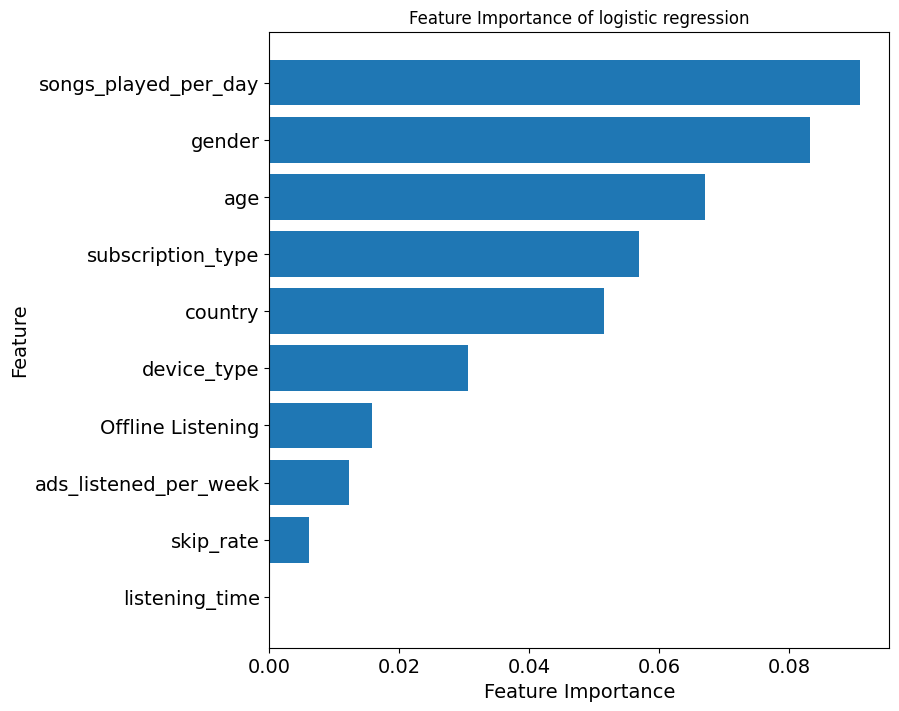

In [ ]:
plt.figure(figsize=(8,8))
plt.barh(feature_importance['Feature'],feature_importance['Feature Importance'])
plt.xlabel('Feature Importance',fontsize = 14)
plt.ylabel('Feature', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Feature Importance of logistic regression')